# Ovarian cancer — survival analysis (Cox vs gradient-boosted survival models)

Follow-up to `Ovarian_cancer_GradientBoosting.ipynb`. The classification "OS > 60 months" had a structural problem:
174 patients were alive but followed for less than 5 years — their class is unknown. They were either
mislabelled as short-term or had to be dropped.

Survival analysis uses them correctly: a censored patient says "survived **at least** *t* months".
The target becomes the pair *(time, event)* = (`OS_MONTHS`, died yes/no).

Plan:
1. Same clinical preprocessing as before; one sample per patient.
2. Kaplan–Meier curves and log-rank tests for key clinical factors.
3. Models: penalised Cox (Coxnet), ridge Cox, **gradient-boosted survival** (`GradientBoostingSurvivalAnalysis`),
   random survival forest — in repeated 5-fold CV.
4. Two feature sets: all clinical features vs **at diagnosis** (no post-treatment follow-up features).
5. Risk stratification of patients (out-of-fold), interpretation, and gene expression with penalised Cox.

Requires `scikit-survival` (`pip install scikit-survival`).

**Metrics**
* **Harrell's C-index** — share of comparable patient pairs ordered correctly by predicted risk (0.5 = random, 1 = perfect).
* **Uno's C-index** — same, corrected for censoring (IPCW).
* **time-dependent AUC at 24 / 36 / 60 months** — "who dies before *t* vs who survives beyond *t*";
  AUC at 60 months is the survival analogue of the previous classification ROC-AUC.
* **Integrated Brier score (IBS)** — calibration + discrimination of predicted survival curves (lower is better;
  ≈ 0.25 is an uninformative model).

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from sksurv.util import Surv
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.metrics import (concordance_index_censored, concordance_index_ipcw,
                            cumulative_dynamic_auc, integrated_brier_score)

warnings.filterwarnings('ignore')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42

## 1. Data

Preprocessing is identical to the previous notebooks (`prepare_clinical`). `OS_STATUS` becomes the event indicator.
17 patients have two samples (primary + recurrence) — one survival time per patient, so the primary sample is kept.

In [2]:
pth1 = 'Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/ClinicalDataCBioportal.csv'
pth2 = 'ClinicalDataCBioportal.csv'
clinical_raw = pd.read_csv(pth1 if os.path.exists(pth1) else pth2, index_col=0, sep=';')

STAGE_MAPPING = {'Stage IA': 1, 'Stage IB': 2, 'Stage IC': 3, 'Stage IIA': 4, 'Stage IIB': 5,
                 'Stage IIC': 6, 'Stage IIIA': 7, 'Stage IIIB': 8, 'Stage IIIC': 9, 'Stage IV': 10}


def prepare_clinical(df):
    df = df.copy()
    for col in ['DFS_MONTHS', 'OS_MONTHS', 'FRACTION_GENOME_ALTERED', 'SPECIMEN_SECOND_LONGEST_DIMENSION',
                'SHORTEST_DIMENSION', 'LONGEST_DIMENSION']:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

    df.drop(['OTHER_PATIENT_ID', 'OTHER_SAMPLE_ID', 'PATHOLOGY_REPORT_FILE_NAME', 'PATHOLOGY_REPORT_UUID',
             'HISTORY_OTHER_MALIGNANCY', 'RETROSPECTIVE_COLLECTION', 'SAMPLE_INITIAL_WEIGHT', 'SEX',
             'TREATMENT_OUTCOME_FIRST_COURSE', 'RADIATION_TREATMENT_ADJUVANT', 'PHARMACEUTICAL_TX_ADJUVANT',
             'PROSPECTIVE_COLLECTION', 'OCT_EMBEDDED'], axis=1, inplace=True)

    df['Survival_Group'] = pd.cut(df['OS_MONTHS'], bins=[-float('inf'), 60, float('inf')],
                                  labels=['short_term_survive', 'long_term_survive'])
    df.dropna(subset=['OS_MONTHS'], inplace=True)

    df['CLINICAL_STAGE_NUM'] = df['CLINICAL_STAGE'].map(STAGE_MAPPING)
    df.drop('CLINICAL_STAGE', axis=1, inplace=True)

    df['IS_HISPANIC'] = (df['ETHNICITY'] == 'HISPANIC OR LATINO').astype(int)
    df['IS_VASCULAR_INVASION_INDICATOR'] = (df['VASCULAR_INVASION_INDICATOR'] == 'YES').astype(int)
    df['WITH_TUMOR'] = (df['TUMOR_STATUS'] == 'WITH TUMOR').astype(int)
    df['NEW_TUMOR_AFT_TREAT'] = (df['NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT'] == 'YES').astype(int)
    df['Ashkenazi'] = (df['JEWISH_RELIGION_HERITAGE_INDICATOR'] == 'ASHKENAZI').astype(int)
    df['IS_LYMPHOVASCULAR_INVASION_INDICATOR'] = (df['LYMPHOVASCULAR_INVASION_INDICATOR'] == 'YES').astype(int)

    # kept aside, not used as features
    df['OS_STATUS_INFO'] = df['OS_STATUS']
    df['PATIENT_ID'] = df['CASE_ID'].str[:12]

    df.drop(['LYMPHOVASCULAR_INVASION_INDICATOR', 'VIAL_NUMBER', 'TMB_NONSYNONYMOUS', 'SOMATIC_STATUS',
             'SAMPLE_TYPE_ID', 'SAMPLE_COUNT', 'OS_STATUS', 'ONCOTREE_CODE', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT',
             'IS_FFPE', 'INITIAL_PATHOLOGIC_DX_YEAR', 'INFORMED_CONSENT_VERIFIED', 'ICD_O_3_SITE',
             'ICD_O_3_HISTOLOGY', 'HISTORY_NEOADJUVANT_TRTYN', 'HISTOLOGICAL_DIAGNOSIS', 'FORM_COMPLETION_DATE',
             'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'DAYS_TO_COLLECTION', 'CANCER_TYPE_DETAILED', 'CANCER_TYPE',
             'TISSUE_SOURCE_SITE'], axis=1, inplace=True)

    df = pd.get_dummies(df, columns=['TUMOR_TISSUE_SITE', 'SAMPLE_TYPE', 'RACE', 'PRIMARY_SITE',
                                     'PERFORMANCE_STATUS_TIMING', 'ICD_10', 'ECOG_SCORE', 'DFS_STATUS',
                                     'GRADE', 'RESIDUAL_TUMOR'])
    df.drop(['ETHNICITY', 'VASCULAR_INVASION_INDICATOR', 'TUMOR_STATUS',
             'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'JEWISH_RELIGION_HERITAGE_INDICATOR'], axis=1, inplace=True)
    return df


clinical_data = prepare_clinical(clinical_raw)

# survival target needs a known status and a positive time
clinical_data = clinical_data[clinical_data['OS_STATUS_INFO'].notna() & (clinical_data['OS_MONTHS'] > 0)]
# one sample per patient: primary first
clinical_data = (clinical_data.sort_values('SAMPLE_TYPE_Primary', ascending=False)
                 .drop_duplicates('PATIENT_ID').sort_index())
print(clinical_data.shape)

(582, 58)


In [3]:
NON_FEATURES = ['OS_MONTHS', 'CASE_ID', 'Survival_Group', 'OS_STATUS_INFO', 'PATIENT_ID']
POST_TREATMENT = ['DFS_MONTHS', 'DFS_STATUS_0_DiseaseFree', 'DFS_STATUS_1_Recurred_Progressed',
                  'NEW_TUMOR_AFT_TREAT', 'WITH_TUMOR']

event = (clinical_data['OS_STATUS_INFO'] == '1:DECEASED').to_numpy()
time = clinical_data['OS_MONTHS'].to_numpy()
y = Surv.from_arrays(event=event, time=time)

X = clinical_data.drop(NON_FEATURES, axis=1).astype(float)
X.columns = X.columns.str.replace(r'[^0-9A-Za-z_]+', '_', regex=True)
X = X.loc[:, X.std() > 0]                                   # constant dummies break Cox
FEATURES_ALL = list(X.columns)
FEATURES_DIAG = [c for c in FEATURES_ALL if c not in POST_TREATMENT]

print(f'Patients: {len(y)} | deaths: {event.sum()} ({event.mean():.0%}) | censored: {(~event).sum()}')
print(f'Features: all = {len(FEATURES_ALL)}, at diagnosis = {len(FEATURES_DIAG)}')
print(f'Censored before 60 months (unusable for the 5-year classification): {((~event) & (time <= 60)).sum()}')

Patients: 582 | deaths: 348 (60%) | censored: 234
Features: all = 53, at diagnosis = 48
Censored before 60 months (unusable for the 5-year classification): 170


## 2. Kaplan–Meier curves

Median overall survival: 45.3 months | 5-year survival: 34.0%


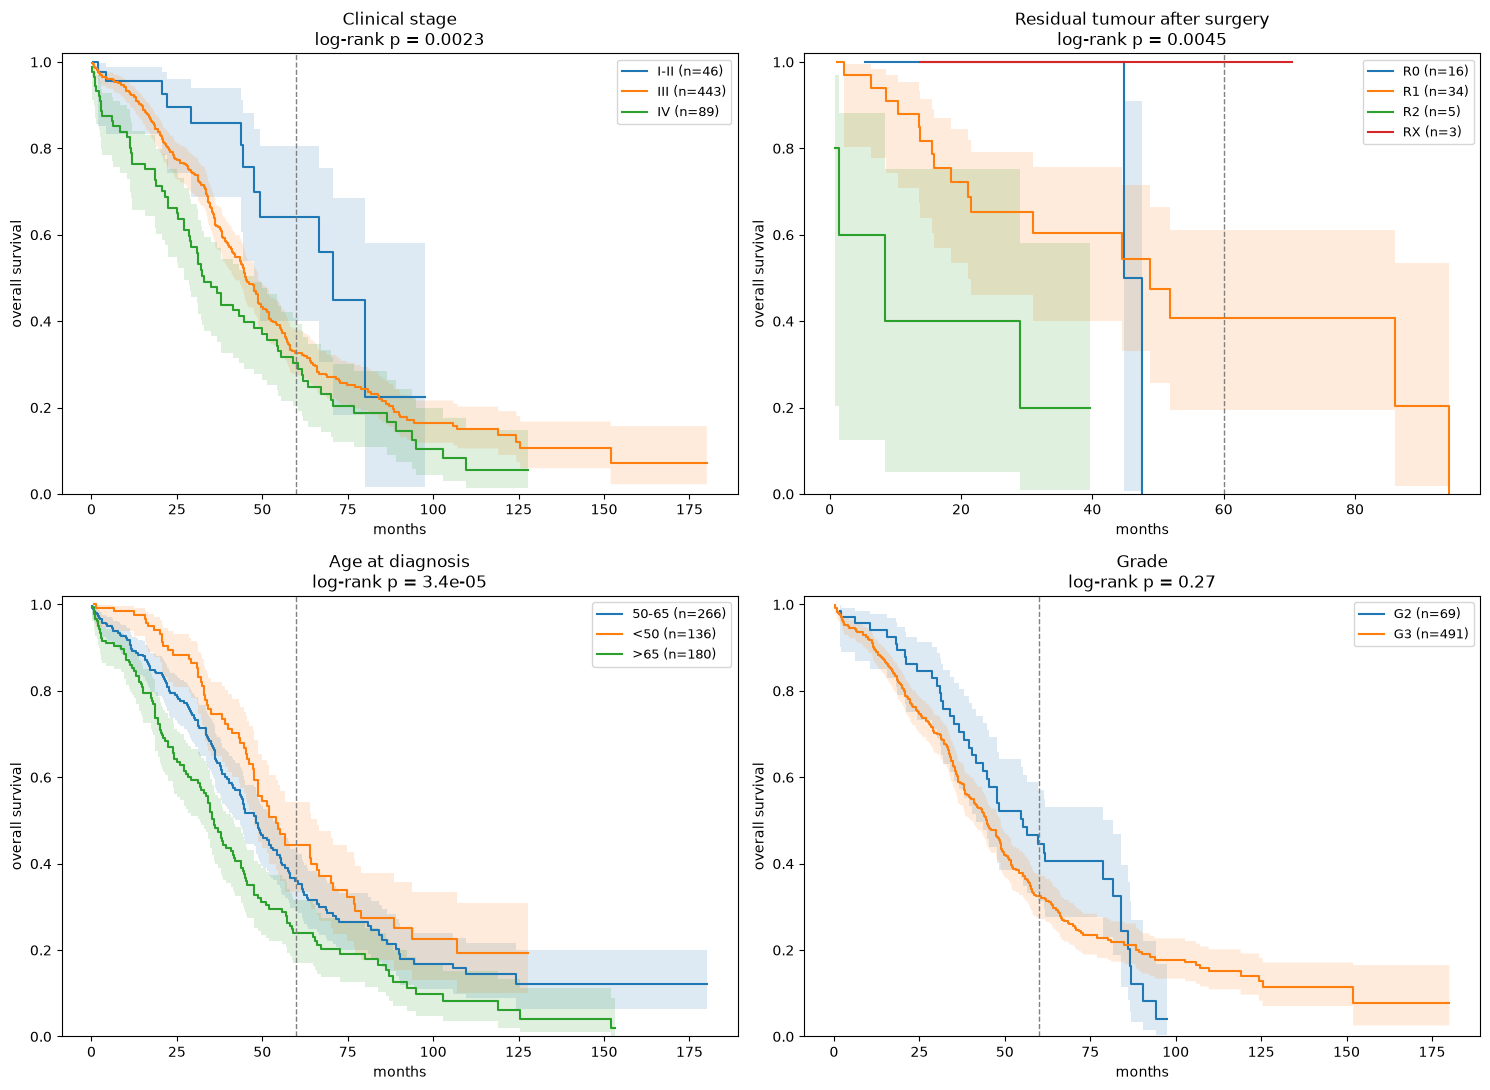

In [4]:
def plot_km(groups, title, ax):
    groups = pd.Series(groups, index=clinical_data.index)
    mask = groups.notna().to_numpy()
    for g in sorted(groups[mask].unique()):
        sel = (groups == g).to_numpy()
        t, s, (lo, hi) = kaplan_meier_estimator(event[sel], time[sel], conf_type='log-log')
        ax.step(t, s, where='post', label=f'{g} (n={sel.sum()})')
        ax.fill_between(t, lo, hi, step='post', alpha=0.15)
    if groups[mask].nunique() > 1:
        _, p = compare_survival(y[mask], groups[mask].astype(str).to_numpy())
        title += f'\nlog-rank p = {p:.2g}'
    ax.axvline(60, color='grey', ls='--', lw=1)
    ax.set(title=title, xlabel='months', ylabel='overall survival', ylim=(0, 1.02))
    ax.legend(fontsize=9)


t, s, (lo, hi) = kaplan_meier_estimator(event, time, conf_type='log-log')
median_os = t[np.argmax(s <= 0.5)]
print(f'Median overall survival: {median_os:.1f} months | 5-year survival: {s[t <= 60][-1]:.1%}')

stage = pd.cut(clinical_data['CLINICAL_STAGE_NUM'], [0, 6, 9, 10], labels=['I-II', 'III', 'IV'])
residual = clinical_data.filter(like='RESIDUAL_TUMOR_').idxmax(axis=1).str.replace('RESIDUAL_TUMOR_', '')
residual[clinical_data.filter(like='RESIDUAL_TUMOR_').sum(axis=1) == 0] = np.nan
age = pd.cut(clinical_data['AGE'], [0, 50, 65, 120], labels=['<50', '50-65', '>65'])
grade = clinical_data.filter(like='GRADE_').idxmax(axis=1).str.replace('GRADE_', '')
grade = grade.where(grade.isin(['G2', 'G3']))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
plot_km(stage, 'Clinical stage', axes[0, 0])
plot_km(residual, 'Residual tumour after surgery', axes[0, 1])
plot_km(age, 'Age at diagnosis', axes[1, 0])
plot_km(grade, 'Grade', axes[1, 1])
plt.tight_layout()
plt.show()

Stage and age separate survival clearly; grade (G2 vs G3) does not. `RESIDUAL_TUMOR` is filled for only 58 of 582
patients, so its curves are based on a handful of events and should not be interpreted — even though residual
disease after surgery is known to be one of the strongest prognostic factors in HGSOC.

## 3. Models in cross-validation

Pipelines (imputation and scaling are fitted inside each fold):

| model | idea |
|---|---|
| `Coxnet` | Cox proportional hazards with elastic-net penalty — linear, analogue of the L1 logistic regression |
| `Cox ridge` | Cox PH with L2 penalty |
| `GB survival` | gradient boosting of regression trees on the Cox partial likelihood — **the gradient-boosting model** |
| `Random survival forest` | bagged survival trees, log-rank splits |

Validation: 5-fold `StratifiedKFold` (stratified by event), repeated 3 times. In each fold the test patients
with time beyond the longest training time are excluded from IPCW-based metrics (the censoring distribution is
unknown there).

In [5]:
EVAL_TIMES = np.array([24, 36, 60])
BRIER_TIMES = np.arange(6, 97, 6)


def make_coxnet(alpha=0.05):
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                         CoxnetSurvivalAnalysis(l1_ratio=0.5, alphas=[alpha], fit_baseline_model=True))


def make_cox_ridge():
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), CoxPHSurvivalAnalysis(alpha=10))


def make_gbsa(**params):
    base = dict(n_estimators=200, learning_rate=0.05, max_depth=2, subsample=0.8, min_samples_leaf=15,
                random_state=SEED)
    return make_pipeline(SimpleImputer(strategy='median'), GradientBoostingSurvivalAnalysis(**(base | params)))


def make_rsf():
    return make_pipeline(SimpleImputer(strategy='median'),
                         RandomSurvivalForest(n_estimators=300, min_samples_leaf=15, max_features='sqrt',
                                              n_jobs=-1, random_state=SEED))


MODELS = {'Coxnet': make_coxnet, 'Cox ridge': make_cox_ridge,
          'GB survival': make_gbsa, 'Random survival forest': make_rsf}


def survival_scores(model, X_tr, y_tr, X_te, y_te):
    risk = model.predict(X_te)
    surv_fns = model.predict_survival_function(X_te)
    surv_prob = np.array([[fn(t) for t in BRIER_TIMES] for fn in surv_fns])
    auc, _ = cumulative_dynamic_auc(y_tr, y_te, risk, EVAL_TIMES)
    return {'C_Harrell': concordance_index_censored(y_te['event'], y_te['time'], risk)[0],
            'C_Uno': concordance_index_ipcw(y_tr, y_te, risk, tau=100)[0],
            **{f'AUC_{t}m': a for t, a in zip(EVAL_TIMES, auc)},
            'IBS': integrated_brier_score(y_tr, y_te, surv_prob, BRIER_TIMES)}


def cv_survival(make_model, X, y, n_repeats=3, return_oof=False):
    scores, oof = [], np.zeros((n_repeats, len(y)))
    for r in range(n_repeats):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=r)
        for tr, te in cv.split(X, y['event']):
            model = make_model().fit(X.iloc[tr], y[tr])
            oof[r, te] = model.predict(X.iloc[te])
            te = te[y['time'][te] < y['time'][tr].max()]
            scores.append(survival_scores(model, X.iloc[tr], y[tr], X.iloc[te], y[te]))
    scores = pd.DataFrame(scores)
    res = scores.mean().to_dict() | {'C_std': scores['C_Harrell'].std()}
    return (res, oof) if return_oof else res

In [6]:
cv_results = {}
for feat_name, feats in {'All features': FEATURES_ALL, 'At diagnosis': FEATURES_DIAG}.items():
    for model_name, make_model in MODELS.items():
        cv_results[f'{feat_name} | {model_name}'] = cv_survival(make_model, X[feats], y)

cols = ['C_Harrell', 'C_std', 'C_Uno', 'AUC_24m', 'AUC_36m', 'AUC_60m', 'IBS']
pd.DataFrame(cv_results).T[cols].round(3)

,C_Harrell,C_std,C_Uno,AUC_24m,AUC_36m,AUC_60m,IBS
All features | Coxnet,0.791,0.023,0.776,0.861,0.842,0.870,0.123
All features | Cox ridge,0.774,0.024,0.763,0.834,0.824,0.859,0.125
All features | GB survival,0.791,0.020,0.775,0.870,0.841,0.856,0.124
All features | Random survival forest,0.787,0.021,0.770,0.868,0.839,0.853,0.137
At diagnosis | Coxnet,0.649,0.028,0.632,0.709,0.701,0.689,0.171
At diagnosis | Cox ridge,0.650,0.028,0.635,0.707,0.703,0.694,0.173
At diagnosis | GB survival,0.641,0.028,0.628,0.700,0.698,0.679,0.173
At diagnosis | Random survival forest,0.619,0.028,0.610,0.677,0.669,0.664,0.179


### Tuning gradient-boosted survival

A small grid over the main capacity parameters, scored by C-index in CV, for the at-diagnosis feature set.
(The grid is evaluated on the same folds, so the best value is slightly optimistic — it is shown only to check
whether a different capacity changes the picture.)

In [7]:
grid = []
for n_estimators, learning_rate in [(100, 0.05), (300, 0.02), (500, 0.01), (200, 0.1)]:
    for max_depth in [1, 2, 3]:
        params = dict(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth)
        res = cv_survival(lambda: make_gbsa(**params), X[FEATURES_DIAG], y, n_repeats=2)
        grid.append(params | {'C_Harrell': res['C_Harrell'], 'AUC_60m': res['AUC_60m']})
pd.DataFrame(grid).sort_values('C_Harrell', ascending=False).round(3).head(8)

,n_estimators,learning_rate,max_depth,C_Harrell,AUC_60m
10,200,0.10,2,0.648,0.687
9,200,0.10,1,0.643,0.687
11,200,0.10,3,0.642,0.672
5,300,0.02,3,0.636,0.660
4,300,0.02,2,0.634,0.664
1,100,0.05,2,0.632,0.659
8,500,0.01,3,0.632,0.656
2,100,0.05,3,0.631,0.656


## 4. Comparison with the classification notebooks

Time-dependent AUC at 60 months answers the same question as the 5-year classifier (died before 5 years vs alive
after 5 years), but uses all patients — censored ones contribute up to their last follow-up.

In [8]:
comparison = pd.DataFrame({
    'Classification ROC-AUC (prev. notebook, clean target)': {'All features': 0.855, 'At diagnosis': 0.684},
    'Survival AUC@60m — Coxnet': {k: cv_results[f'{k} | Coxnet']['AUC_60m'] for k in ['All features', 'At diagnosis']},
    'Survival AUC@60m — GB survival': {k: cv_results[f'{k} | GB survival']['AUC_60m'] for k in ['All features', 'At diagnosis']},
})
comparison.round(3)

,"Classification ROC-AUC (prev. notebook, clean target)",Survival AUC@60m — Coxnet,Survival AUC@60m — GB survival
All features,0.855,0.870,0.856
At diagnosis,0.684,0.689,0.679


## 5. Risk stratification at diagnosis

Out-of-fold risk scores (each patient scored by a model that never saw them) are split into tertiles.
If the model is useful, the three risk groups should have clearly separated survival curves.

Coxnet
   group   n  median OS, months  5-year OS
   1 low 188              63.04       0.52
2 medium 204              44.88       0.28
  3 high 190              33.64       0.21



GB survival
   group   n  median OS, months  5-year OS
   1 low 189              61.66       0.51
2 medium 211              44.51       0.29
  3 high 182              33.64       0.21



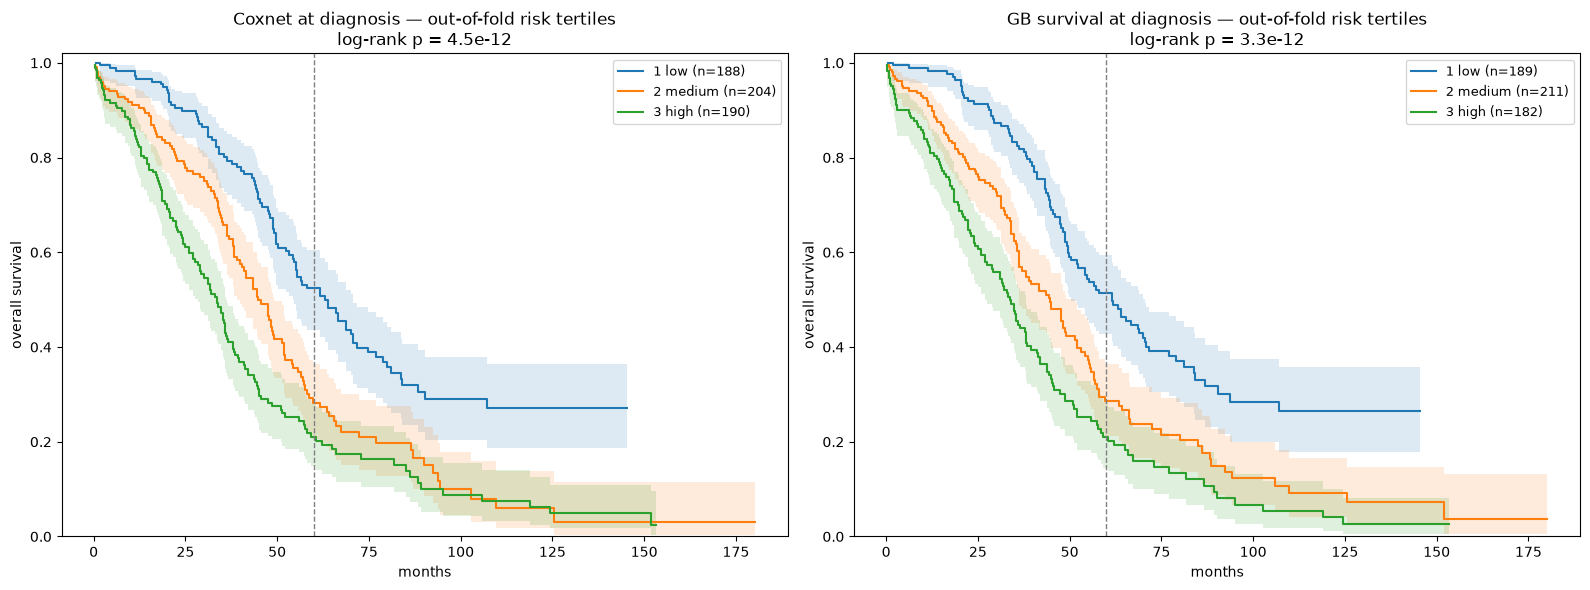

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, make_model) in zip(axes, [('Coxnet', make_coxnet), ('GB survival', make_gbsa)]):
    _, oof = cv_survival(make_model, X[FEATURES_DIAG], y, n_repeats=3, return_oof=True)
    # average rank across repeats -> one out-of-fold risk per patient
    risk_rank = pd.DataFrame(oof.T).rank(pct=True).mean(axis=1).to_numpy()
    risk_group = pd.cut(risk_rank, [0, 1/3, 2/3, 1], labels=['1 low', '2 medium', '3 high'], include_lowest=True)
    plot_km(np.asarray(risk_group), f'{name} at diagnosis — out-of-fold risk tertiles', ax)

    g = pd.Series(np.asarray(risk_group))
    summary = []
    for grp in ['1 low', '2 medium', '3 high']:
        sel = (g == grp).to_numpy()
        t, s = kaplan_meier_estimator(event[sel], time[sel])
        summary.append({'group': grp, 'n': sel.sum(), 'median OS, months': t[np.argmax(s <= 0.5)] if (s <= 0.5).any() else np.nan,
                        '5-year OS': s[t <= 60][-1]})
    print(name); print(pd.DataFrame(summary).round(2).to_string(index=False)); print()
plt.tight_layout()
plt.show()

## 6. Interpretation

* **Coxnet**: coefficients of standardised features → hazard ratio per 1 SD (`HR > 1` = higher risk of death).
* **GB survival**: permutation importance — drop of C-index on held-out patients when a feature is shuffled.

Hold-out C-index: Coxnet 0.651 | GB survival 0.646


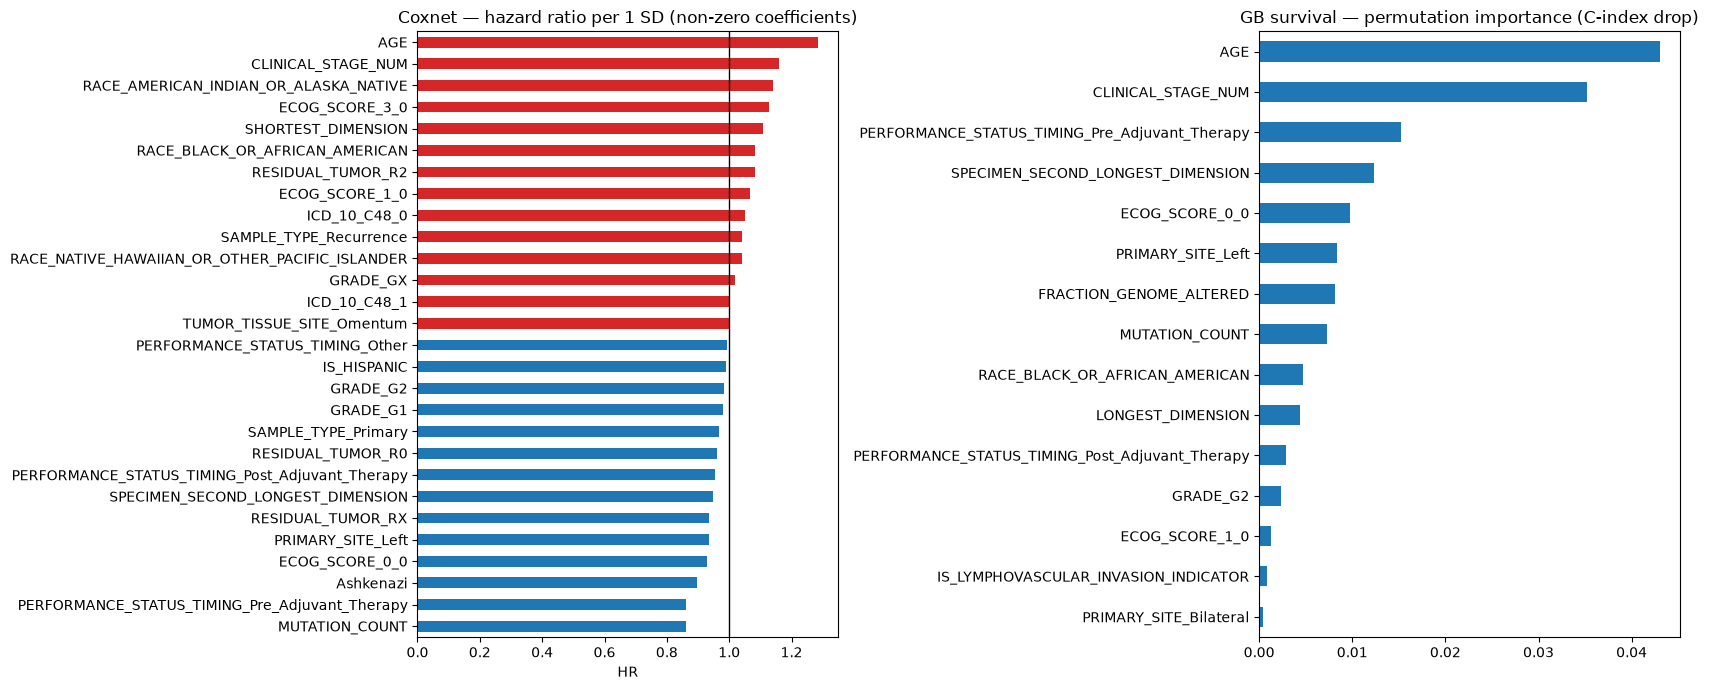

In [10]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X[FEATURES_DIAG], y, test_size=0.25, random_state=SEED,
                                          stratify=y['event'])

coxnet = make_coxnet().fit(X_tr, y_tr)
coefs = pd.Series(coxnet[-1].coef_.ravel(), index=FEATURES_DIAG)
hr = np.exp(coefs[coefs != 0]).sort_values()

gbsa = make_gbsa().fit(X_tr, y_tr)
perm = permutation_importance(gbsa, X_te, y_te, n_repeats=30, random_state=SEED)   # score() = C-index
perm_imp = pd.Series(perm.importances_mean, index=FEATURES_DIAG).sort_values(ascending=False)

print('Hold-out C-index: Coxnet', round(coxnet.score(X_te, y_te), 3), '| GB survival', round(gbsa.score(X_te, y_te), 3))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
hr.plot(kind='barh', ax=axes[0], color=np.where(hr > 1, 'tab:red', 'tab:blue'))
axes[0].axvline(1, color='k', lw=1)
axes[0].set(title='Coxnet — hazard ratio per 1 SD (non-zero coefficients)', xlabel='HR')
perm_imp.head(15).sort_values().plot(kind='barh', ax=axes[1], title='GB survival — permutation importance (C-index drop)')
plt.tight_layout()
plt.show()

## 7. Gene expression with penalised Cox (optional, ~1–2 min)

The classification notebook selected genes by a univariate test, which overfitted. The standard approach for
survival is a penalised Cox model on all candidate genes at once — the elastic-net penalty does the selection.
Same gene preprocessing as before: `log1p`, genes expressed in ≥ 50% of samples, top 5000 by variance.

In [11]:
RUN_GENES = True

if RUN_GENES:
    pth1 = 'Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/GeneExpressionDataTCGA.csv'
    pth2 = 'GeneExpressionDataTCGA.csv'
    gene_expression = pd.read_csv(pth1 if os.path.exists(pth1) else pth2, index_col=0, sep=';', decimal=',')
    genes = np.log1p(gene_expression.T.astype('float32'))
    genes.index = genes.index.str[:15]
    genes = genes.loc[:, (genes > np.log1p(1)).mean() > 0.5]
    genes = genes[genes.var().nlargest(5000).index]

    X_ids = X.set_index(clinical_data['CASE_ID'].to_numpy())
    has_genes = X_ids.index.isin(genes.index)
    X_g = X_ids[has_genes][FEATURES_DIAG].join(genes)
    y_g = y[has_genes]
    gene_cols = list(genes.columns)
    print('Patients with expression data:', len(y_g))

    gene_results = {}
    gene_results['Clinical at diagnosis'] = cv_survival(make_coxnet, X_g[FEATURES_DIAG], y_g)
    for alpha in [0.05, 0.1, 0.2]:
        gene_results[f'Genes only, alpha={alpha}'] = cv_survival(lambda: make_coxnet(alpha), X_g[gene_cols], y_g)
        gene_results[f'Clinical + genes, alpha={alpha}'] = cv_survival(lambda: make_coxnet(alpha), X_g, y_g)
    display(pd.DataFrame(gene_results).T[['C_Harrell', 'C_std', 'AUC_60m', 'IBS']].round(3))

Patients with expression data: 419


,C_Harrell,C_std,AUC_60m,IBS
Clinical at diagnosis,0.637,0.042,0.685,0.170
"Genes only, alpha=0.05",0.599,0.044,0.595,0.219
"Clinical + genes, alpha=0.05",0.615,0.044,0.624,0.216
"Genes only, alpha=0.1",0.605,0.043,0.609,0.189
"Clinical + genes, alpha=0.1",0.636,0.039,0.646,0.181
"Genes only, alpha=0.2",0.591,0.037,0.599,0.180
"Clinical + genes, alpha=0.2",0.619,0.042,0.641,0.176


## 8. Summary

In [12]:
pd.DataFrame(cv_results).T[cols].round(3)

,C_Harrell,C_std,C_Uno,AUC_24m,AUC_36m,AUC_60m,IBS
All features | Coxnet,0.791,0.023,0.776,0.861,0.842,0.870,0.123
All features | Cox ridge,0.774,0.024,0.763,0.834,0.824,0.859,0.125
All features | GB survival,0.791,0.020,0.775,0.870,0.841,0.856,0.124
All features | Random survival forest,0.787,0.021,0.770,0.868,0.839,0.853,0.137
At diagnosis | Coxnet,0.649,0.028,0.632,0.709,0.701,0.689,0.171
At diagnosis | Cox ridge,0.650,0.028,0.635,0.707,0.703,0.694,0.173
At diagnosis | GB survival,0.641,0.028,0.628,0.700,0.698,0.679,0.173
At diagnosis | Random survival forest,0.619,0.028,0.610,0.677,0.669,0.664,0.179


**Conclusions**

1. **Survival models use all patients**, including those censored before 5 years, instead of mislabelling or dropping
   them — the methodologically correct framing for this data.
2. **Gradient boosting again does not beat the linear model.** With all clinical features GB survival, the random
   survival forest and Coxnet reach practically the same C-index ≈ 0.79 and AUC@60m ≈ 0.85–0.87; at diagnosis
   Cox models are equal or slightly better (C ≈ 0.65 vs 0.64, AUC@60m ≈ 0.69 vs 0.68). Tuning the boosting capacity does not change
   this. The relationships in these clinical variables are close to linear/additive, and ~580 patients are not
   enough for trees to find reliable interactions.
3. Discrimination is **the same as in the classification approach** (AUC@60m vs ROC-AUC), but now it comes with
   full survival curves, calibrated probabilities (IBS) and no lost patients.
4. **At diagnosis the prognosis is only moderately predictable** (C ≈ 0.65). Still, out-of-fold risk tertiles split
   patients into groups with clearly different survival (5-year OS 52% / 28% / 21%, median 63 / 45 / 34 months,
   log-rank p ≈ 1e-11) — usable for risk stratification, not for individual
   prediction.
5. Gene expression (top-variance genes, penalised Cox) carries a weak signal on its own and does not improve
   the clinical model — consistent with the known difficulty of transcriptomic prognosis in TCGA ovarian cancer.

**Possible next steps**
* published HGSOC molecular subtypes / prognostic signatures as a few compact features instead of 5000 genes;
* treat `RESIDUAL_TUMOR` and stage carefully (cleaner categories, missing-value indicator);
* external validation on another cohort (e.g. ICGC or GEO ovarian datasets).